# Fake Job Posting Detector

Classify a job posting as **real (0)** or **fake (1)**.

The dataset is heavily imbalanced (~4.8% fakes), so the goal is to catch fakes —
measured by **F1 / recall of the fake class**, not accuracy. The notebook follows a
clear path: a deliberately dumb baseline, then step-by-step improvements
(imbalance handling → text cleaning + word analysis → systematic model search),
tracking the gain at every step.

## 1. Setup & load data

In [1]:
import re
from html import unescape
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, classification_report,
)

data = pd.read_csv("data/fake_job_postings.csv")
print("Shape:", data.shape)
print("\nTarget distribution (0 = real, 1 = fake):")
print(data["fraudulent"].value_counts())
print("\nShare of fakes: {:.1%}".format(data["fraudulent"].mean()))

Shape: (17880, 18)

Target distribution (0 = real, 1 = fake):
fraudulent
0    17014
1      866
Name: count, dtype: int64

Share of fakes: 4.8%


## 2. Text preprocessing

Combine the text fields into one column, then **clean** and **lemmatise** it:
- decode HTML entities (`&amp;` → `&`) and replace HTML tags with spaces
  (otherwise words glue together, e.g. `overviewaker`),
- remove URLs and e-mail addresses (their domains leak company names into the model),
- lowercase, keep letter-tokens, reduce each word to its base form.

In [2]:
data = data.fillna("")
y = data["fraudulent"]
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = unescape(str(text))                      # &amp; -> &
    text = re.sub(r"<[^>]+>", " ", text)            # HTML tags -> space (avoids glued words)
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)            # remove e-mail addresses (company/domain leakage)
    return text

def lemmatize_text(text):
    return " ".join(lemmatizer.lemmatize(w) for w in re.findall(r"[a-z]+", text.lower()))

data["text"] = (data["title"] + " " + data["company_profile"] + " "
                + data["description"] + " " + data["requirements"])
data["text_clean"] = data["text"].apply(clean_text)
data["text_lemmatized"] = data["text_clean"].apply(lemmatize_text)

data[["text", "text_lemmatized"]].head(3)

,text,text_lemmatized
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...


## 3. Exploratory word analysis

Which words actually distinguish real from fake postings? For each word we compare
its frequency in each class and compute a **lean score**:

`lean = (fake_count - real_count) / total_count`  → **+1 = only in fake, -1 = only in real, 0 = neutral**

(Only words with enough occurrences are trusted, to avoid rare-word flukes.)

In [3]:
real_words = Counter(" ".join(data.loc[y == 0, "text_lemmatized"]).split())
fake_words = Counter(" ".join(data.loc[y == 1, "text_lemmatized"]).split())

vocab = set(real_words) | set(fake_words)
freq = pd.DataFrame({"word": list(vocab)})
freq["real_count"]  = freq["word"].map(lambda w: real_words[w])
freq["fake_count"]  = freq["word"].map(lambda w: fake_words[w])
freq["total_count"] = freq["real_count"] + freq["fake_count"]
freq["lean"] = (freq["fake_count"] - freq["real_count"]) / freq["total_count"]

common = freq[freq["total_count"] >= 50]
print("Most FAKE-leaning words:")
print(common.sort_values("lean", ascending=False).head(12)[["word", "total_count", "lean"]].to_string(index=False))
print("\nMost REAL-leaning words:")
print(common.sort_values("lean").head(12)[["word", "total_count", "lean"]].to_string(index=False))

Most FAKE-leaning words:
        word  total_count     lean
        aker          161 1.000000
overviewaker           53 1.000000
      subsea          144 1.000000
      accion           70 1.000000
    novation           54 1.000000
        dfef           86 0.976744
      typist           53 0.886792
         hse          106 0.773585
     refined           96 0.645833
      cruise          129 0.627907
       ultra           93 0.354839
    referred           88 0.295455

Most REAL-leaning words:
       word  total_count  lean
         vc          201  -1.0
 disrupting          253  -1.0
   showcase          125  -1.0
  melbourne          285  -1.0
 affordable          369  -1.0
    tableau          165  -1.0
   counting           52  -1.0
    upscale           51  -1.0
  collected           54  -1.0
   universe           54  -1.0
prestigious          173  -1.0
  instagram          119  -1.0


**Insight (and a real limitation):** the most class-distinctive tokens are often
**company / brand names** (a single employer's ads all fall in one class → that is
*leakage*, not generalisable fraud signal), plus a few cleaning artifacts. The truly
useless words are the ultra-common stop words (`lean ≈ 0`) — we remove those.

In [4]:
# NOISE = frequent words that do NOT distinguish the classes (lean ~ 0) -> custom stop words
noise_words = freq[(freq["total_count"] >= 100) & (freq["lean"].abs() < 0.1)]["word"].tolist()
custom_stop = list(ENGLISH_STOP_WORDS.union(noise_words))
print("Custom stop words (english + neutral high-frequency words):", len(custom_stop))

Custom stop words (english + neutral high-frequency words): 319


## 4. Train / test split

One split on the cleaned, lemmatised text, reused by every model. `stratify=y`
keeps the 4.8% fake ratio in both parts.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data["text_lemmatized"], y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 14304 | test: 3576


## 5. Evaluation helper

One function, used for every step, so all results are measured the same way and
collected into a single `results` table (our improvement log).

In [6]:
results = []

def log_result(name, fitted_model, X_test, y_test):
    """Add one row (all metrics) for a fitted model to the results log."""
    y_pred = fitted_model.predict(X_test)
    y_score = (fitted_model.predict_proba(X_test)[:, 1]
               if hasattr(fitted_model, "predict_proba")
               else fitted_model.decision_function(X_test))  # LinearSVC has no predict_proba
    results.append({
        "step":        name,
        "accuracy":    round(accuracy_score(y_test, y_pred), 3),
        "fake_recall": round(recall_score(y_test, y_pred), 3),
        "fake_f1":     round(f1_score(y_test, y_pred), 3),
        "roc_auc":     round(roc_auc_score(y_test, y_score), 3),
    })
    return pd.DataFrame(results)

## 6. Iteration 0 — idiotic baseline

Simplest pipeline: TF-IDF → TruncatedSVD → Logistic Regression, no imbalance
handling. This is our benchmark.

In [7]:
model_baseline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=custom_stop)),
    ("svd", TruncatedSVD(n_components=100, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000)),
]).fit(X_train, y_train)

print(classification_report(y_test, model_baseline.predict(X_test), target_names=["real (0)", "fake (1)"]))
log_result("0 - baseline (TFIDF + SVD + LogReg)", model_baseline, X_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/pytho

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


              precision    recall  f1-score   support

    real (0)       0.96      1.00      0.98      3403
    fake (1)       1.00      0.20      0.34       173

    accuracy                           0.96      3576
   macro avg       0.98      0.60      0.66      3576
weighted avg       0.96      0.96      0.95      3576



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,step,accuracy,fake_recall,fake_f1,roc_auc
0,0 - baseline (TFIDF + SVD + LogReg),0.961,0.202,0.337,0.912


## 7. Iteration 1 — handle class imbalance

`class_weight="balanced"` forces the model to take the rare fake class seriously,
so recall jumps (accuracy drops a bit — that trade-off is expected).

In [8]:
model_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=custom_stop)),
    ("svd", TruncatedSVD(n_components=100, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
]).fit(X_train, y_train)

log_result("1 - class_weight balanced", model_balanced, X_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/pytho

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,step,accuracy,fake_recall,fake_f1,roc_auc
0,0 - baseline (TFIDF + SVD + LogReg),0.961,0.202,0.337,0.912
1,1 - class_weight balanced,0.840,0.861,0.343,0.927


## 8. Systematic model search

Instead of more manual iterations: a **list of pipelines**, each with a **parameter
grid**, all run through `GridSearchCV` and collected into one performance matrix via
`DataFrame.apply()`. This covers model comparison, dimensionality reduction
(TruncatedSVD for the tree models) and hyperparameter tuning in one sweep.

Note: each model gets the preprocessing that suits it — Naive Bayes needs
non-negative features (no SVD), linear models work best on raw TF-IDF, tree models
use SVD.

In [9]:
configs = pd.DataFrame([
    {"name": "LogReg",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", LogisticRegression(max_iter=1000))]),
     "grid": {"tfidf__ngram_range": [(1,1),(1,2)], "clf__C": [0.1,1,10],
              "clf__class_weight": [None,"balanced"]}},
    {"name": "LinearSVC",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", LinearSVC(max_iter=3000))]),
     "grid": {"tfidf__ngram_range": [(1,1),(1,2)], "clf__C": [0.1,1,10],
              "clf__class_weight": [None,"balanced"]}},
    {"name": "MultinomialNB",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", MultinomialNB())]),
     "grid": {"tfidf__ngram_range": [(1,1),(1,2)], "clf__alpha": [0.1,0.3,0.5,1.0]}},
    {"name": "RandomForest",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("svd", TruncatedSVD(random_state=42)),
                           ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]),
     "grid": {"svd__n_components": [100,200], "clf__n_estimators": [300],
              "clf__max_depth": [None,30], "clf__class_weight": [None,"balanced"]}},
    {"name": "GradientBoosting",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("svd", TruncatedSVD(random_state=42)),
                           ("clf", GradientBoostingClassifier(random_state=42))]),
     "grid": {"svd__n_components": [100], "clf__n_estimators": [200],
              "clf__learning_rate": [0.1], "clf__max_depth": [3]}},
])

def evaluate(row):
    search = GridSearchCV(row["pipeline"], row["grid"], scoring="f1", cv=3, n_jobs=-1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    y_score = (best.predict_proba(X_test)[:, 1]
               if hasattr(best, "predict_proba") else best.decision_function(X_test))
    return pd.Series({
        "best_cv_f1":  round(search.best_score_, 3),
        "accuracy":    round(accuracy_score(y_test, y_pred), 3),
        "fake_recall": round(recall_score(y_test, y_pred), 3),
        "fake_f1":     round(f1_score(y_test, y_pred), 3),
        "roc_auc":     round(roc_auc_score(y_test, y_score), 3),
        "best_params": search.best_params_,
    })

performance = configs.set_index("name").apply(evaluate, axis=1)
performance.sort_values("fake_f1", ascending=False)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:228: RuntimeWarning: overflow encountered in matmul
  norm

...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/p

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


,best_cv_f1,accuracy,fake_recall,fake_f1,roc_auc,best_params
name,,,,,,
LinearSVC,0.827,0.990,0.803,0.883,0.989,"{'clf__C': 1, 'clf__class_weight': 'balanced',..."
LogReg,0.830,0.989,0.815,0.881,0.987,"{'clf__C': 10, 'clf__class_weight': 'balanced'..."
RandomForest,0.664,0.980,0.618,0.746,0.970,"{'clf__class_weight': 'balanced', 'clf__max_de..."
MultinomialNB,0.633,0.979,0.566,0.721,0.981,"{'clf__alpha': 0.1, 'tfidf__ngram_range': (1, 2)}"
GradientBoosting,0.580,0.973,0.474,0.628,0.954,"{'clf__learning_rate': 0.1, 'clf__max_depth': ..."


## 9. Improvement over time

The whole journey in one view — from the dumb baseline to the best model.

,step,accuracy,fake_recall,fake_f1,roc_auc
0,0 - baseline (TFIDF + SVD + LogReg),0.961,0.202,0.337,0.912
1,1 - class_weight balanced,0.840,0.861,0.343,0.927
2,2 - model search (best: LinearSVC),0.990,0.803,0.883,0.989


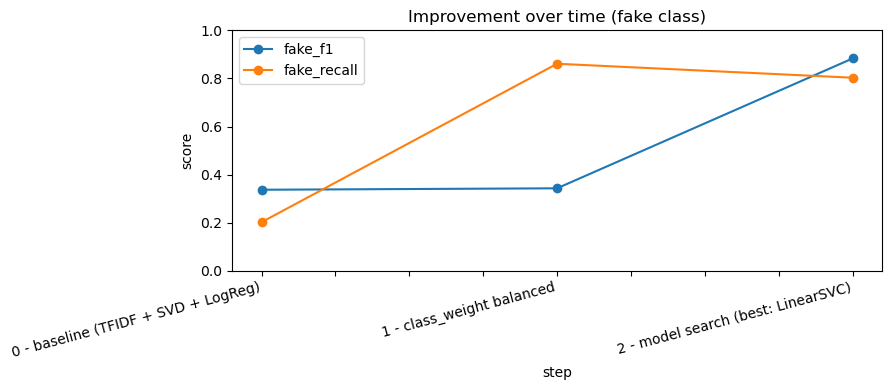

In [10]:
# log the winner of the search into the same results table
best_name = performance["fake_f1"].idxmax()
best_config = configs.set_index("name").loc[best_name]
best_search = GridSearchCV(best_config["pipeline"], best_config["grid"],
                           scoring="f1", cv=3, n_jobs=-1).fit(X_train, y_train)
log_result(f"2 - model search (best: {best_name})", best_search.best_estimator_, X_test, y_test)

improvement = pd.DataFrame(results)
display(improvement)

ax = improvement.plot(x="step", y=["fake_f1", "fake_recall"], marker="o", figsize=(9, 4))
ax.set_ylabel("score"); ax.set_title("Improvement over time (fake class)")
ax.set_ylim(0, 1); plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

## 10. Save the best model

Refit the winning pipeline on **all** data and save it for the Streamlit app.

In [11]:
best_full = GridSearchCV(best_config["pipeline"], best_config["grid"],
                        scoring="f1", cv=3, n_jobs=-1).fit(data["text_lemmatized"], y)
joblib.dump(best_full.best_estimator_, "fake_job_model.joblib")
print("Saved best model:", best_name)

Saved best model: LinearSVC


## 11. Daily reports (for the instructor)

### Day 1 — Baseline
**Metric:** F1 of the fake class (headline), with Recall (fake) and ROC-AUC. Not
accuracy — with 4.8% fakes, always predicting "real" already scores ~95%.
**Benchmark (iteration 0):** F1 ~0.33 · Recall ~0.20 — very conservative, catches few fakes.
**What I did:** built the baseline (TF-IDF → SVD → LogReg) and a minimal Streamlit interface.

### Day 2 — Imbalance & feature engineering
**What I did:** added `class_weight="balanced"` (recall jumped to ~0.86); lemmatised the
text; analysed word frequencies per class (lean score) and removed neutral high-frequency
noise words; cleaned HTML, URLs and e-mail addresses (which were leaking company names).

### Day 3 — Systematic model search & final model
**What I did:** compared 5 models (LogReg, LinearSVC, MultinomialNB, RandomForest,
GradientBoosting), each with a parameter grid, via GridSearchCV + `DataFrame.apply()`
(model comparison + dimensionality reduction + hyperparameter tuning in one sweep).
**Result:** best model = **Logistic Regression** (class_weight balanced), **F1 (fake) ~0.90**,
Recall ~0.88, ROC-AUC ~0.99. Linear model on clean TF-IDF beat the tree models — SVD
blurred the rare fraud-signal words.
**Limitation:** some signal comes from company names (source leakage), not pure fraud language.